# pycream2 demo

`pycream2` fits multi-band AGN light curves as a delayed, smoothed echo of a
shared driving light curve, using a fully Bayesian (NUTS) joint fit across
all bands at once -- see `README.md` for the science background and full
model writeup.

This notebook is a hands-on, section-by-section walkthrough of everything
`EchoFit` does: generating synthetic multi-band reverberation-mapping data,
fitting it with NUTS and with the much faster direct solve (`optimise()`,
a nested Laplace approximation), inspecting and visualising the posterior and
its Badness-of-Fit landscape, saving/
resuming managed fit runs, using your own real light curves, and swapping
in a different response function.

Runs end-to-end on synthetic data in a few minutes on CPU.


## Contents

- [Setup](#setup)
- [1. The model, in brief](#model)
- [2. Generate synthetic data](#synthetic-data)
- [3. Build the `EchoFit` object](#build-echofit)
- [4. Fit with NUTS](#fit-nuts)
- [5. Inspect the posterior](#inspect-posterior)
- [6. Visualise the fit](#visualise-fit)
- [7. Sanity check against ground truth](#sanity-check)
- [8. The fast direct solve: `optimise()` and the Badness-of-Fit landscape](#direct-solve)
- [9. Fixing parameters (e.g. assuming a face-on disk)](#fixed-params)
- [10. Error-bar rescaling (fit_error_model)](#error-model)
- [11. Managed, resumable runs for real fitting campaigns](#managed-runs)
- [12. Using your own real light curves](#real-data)
- [13. Swapping the response function](#swap-response)
- [14. Extra components: diffuse continuum and slow backgrounds](#extra-components)
- [15. Disc SED, luminosity distance and H0](#disc-sed)
- [16. Rimmed and rippled discs](#rippled-disc)
- [Next steps](#next-steps)

<a id="setup"></a>

## Setup

In [1]:
import os
import numpy as np

from pycream2 import EchoFit, generate_synthetic_dataset

<a id="model"></a>

## 1. The model, in brief

Each band's light curve is modelled as a **delayed, smoothed echo** of a
single shared, unobserved driving light curve:

```
y_band(t) = S_band * (X ⋆ ψ)(t; λ_band, θ) + C_band + noise
```

- **Driver `X(t)`**: a stochastic process, represented as a *fixed*
  truncated Fourier series `X(t) = Σ_k [S_k sin(w_k t) + C_k cos(w_k t)]`.
  By default (`drw_prior=False`) the Fourier amplitudes' *prior* scale
  follows a pure random-walk (RW) power law, `P(w) = sigma_drw**2 / w**2`,
  with `sigma_drw` (amplitude) the only hyperparameter. Pass
  `EchoFit(drw_prior=True)` for the original damped random walk (DRW)
  instead -- a Lorentzian power spectrum with a second hyperparameter,
  `tau_drw` (damping timescale, days), inferred alongside `sigma_drw`. See
  `README.md`'s "Random-walk vs. damped random-walk driver prior" section.
- **Response `ψ(τ; λ, θ)`**: a causal (`τ ≥ 0`), positive, skew-normal
  function. Its **mean lag** follows the standard thin-disk reprocessing
  scaling `τ_mean ∝ M_BH^(2/3) · Ṁ^(1/3) · λ^(4/3)`, with `M_BH` **fixed**
  (never inferred -- pass what you already know/assume) and `log_mdot`
  (accretion rate) inferred. **Inclination only controls the response's
  skewness**, never the mean lag.
- **Convolution**: because the driver is a finite sum of sinusoids, the
  convolution `X ⋆ ψ` has a closed form (via `ψ`'s own Fourier transform) --
  no numerical double-integration over `(t, τ)`.

Inferred parameters: `log_mdot`, `inclination`, `sigma_drw`, the driver's
`{S_k, C_k}`, and per-band `{S_band, C_band}` (a linear stretch/offset
absorbing each band's own flux calibration) -- `tau_drw` too if
`drw_prior=True`.

<a id="synthetic-data"></a>

## 2. Generate synthetic data

`generate_synthetic_dataset` draws a DRW driver realisation, echoes it into
each band with the *true* forward model, and adds Gaussian noise -- useful
for demos, tests, and sanity-checking the code, though (being generated
*with* the same model used to fit it) it's not a substitute for validation
against independent simulations or real campaigns.

**A practical gotcha worth internalising**: the mean lag has to be
*resolvable* against your sampling cadence, or the fit has nothing to
constrain it with. A tiny `M_BH`/short-wavelength/high-accretion-rate
combination can produce lags of well under a day -- shorter than typical
survey cadence -- in which case no amount of data or MCMC tuning will
recover the reprocessing parameters. Below we pick `M_BH` large enough that
mean lags are several days, comfortably above the ~1-day-ish cadence.

We also inject two **observing gaps** (`gaps=[(50, 14), (150, 21)]`: a
2-week gap starting day 50, a 3-week gap starting day 150) -- real
campaigns have weather/scheduling downtime, and it's a good stress test of
`EchoFit.build_grid()`'s cadence-estimation heuristic.

In [2]:
M_BH_TRUE = 1.0e9  # solar masses -- fixed/known, sets the lag scale

data = generate_synthetic_dataset(
    M_BH=M_BH_TRUE,
    log_mdot_true=0.1,
    inclination_true=40.0,
    sigma_drw_true=0.3,
    tau_drw_true=25.0,
    bands={"g": 4770.0, "r": 6231.0, "i": 7625.0},
    t_span=200.0,
    n_obs_per_band=45,
    n_freq=25,
    n_tau=150,
    tau_max=50.0,
    noise_level=0.05,
    gaps=[(50, 14), (150, 21)],
    seed=0,
)

# The generator draws its driver with a longest period equal to the baseline;
# build_grid() defaults to a longer one (2 x (baseline + tau_max)), which real,
# red-noise drivers need. To fit this synthetic set on its own basis, every
# build_grid() below passes period_max=PERIOD_MAX.
PERIOD_MAX = 2 * np.pi / float(data["freqs"].min())

for name, d in data["bands"].items():
    print(f"{name}: {len(d['t'])} points, wavelength={d['wavelength']:.0f} Å, "
          f"true mean lag={data['truth']['bands'][name]['tau_mean']:.2f} days")

g: 45 points, wavelength=4770 Å, true mean lag=5.97 days
r: 45 points, wavelength=6231 Å, true mean lag=8.53 days
i: 45 points, wavelength=7625 Å, true mean lag=11.16 days


<a id="build-echofit"></a>

## 3. Build the `EchoFit` object

- `EchoFit(M_BH=...)`: `M_BH` is the one physical quantity that's always
  fixed, never inferred.
- `add_lightcurve(name, wavelength, t, y, yerr, fit_error_model=False)`:
  register each band. Order doesn't matter -- `EchoFit` sorts by wavelength
  internally for plotting. `fit_error_model=True` (per band, off by
  default) fits that band's own `sigma_scale`/`sigma_jitter` nuisance
  parameters instead of trusting `yerr` exactly -- a direct adaptation of
  the author's PhD-era CREAM Fortran code's `sigexpand`/`varexpand`
  parameters (`docs/mcmc_implementation.md`, `CLAUDE.md` decision #18),
  worth turning on for any band whose quoted errors you don't fully trust.
- `build_grid(n_freq, n_tau, tau_max, dt_min)`: builds the driver's fixed
  Fourier frequency grid and the lag grid `ψ` is evaluated on.
  - `n_freq` sets how many Fourier components the driver can use -- more
    resolves finer structure, at the cost of more latent parameters.
  - `tau_max` should comfortably exceed the largest lag you expect
    (defaults to half the time baseline).
  - `dt_min` sets the frequency grid's upper bound (`w_max = pi / dt_min`).
    Left as default, it's a robust (5th-percentile) estimate of the actual
    observation gaps in your data -- pass it explicitly if you have a known
    cadence you'd rather target directly.

In [3]:
ef = EchoFit(M_BH=M_BH_TRUE)

for name, d in data["bands"].items():
    ef.add_lightcurve(name, wavelength=d["wavelength"], t=d["t"], y=d["y"], yerr=d["yerr"])

ef.build_grid(n_freq=25, n_tau=150, period_max=PERIOD_MAX)

# ef.freqs is angular frequency (rad/day) internally -- the driver's own
# Fourier series needs that -- but cycles/day (f = w / (2*pi)) is easier
# to read, so that's what every plot/printed diagnostic shows instead.
freqs_cycles = np.asarray(ef.freqs) / (2 * np.pi)
print(f"frequency grid: {len(ef.freqs)} points, "
      f"{freqs_cycles.min():.4f} to {freqs_cycles.max():.4f} cycles/day")
print(f"lag grid: {len(ef.tau_grid)} points, up to {float(ef.tau_grid.max()):.1f} days")

frequency grid: 25 points, 0.0050 to 2.0004 cycles/day
lag grid: 150 points, up to 99.5 days


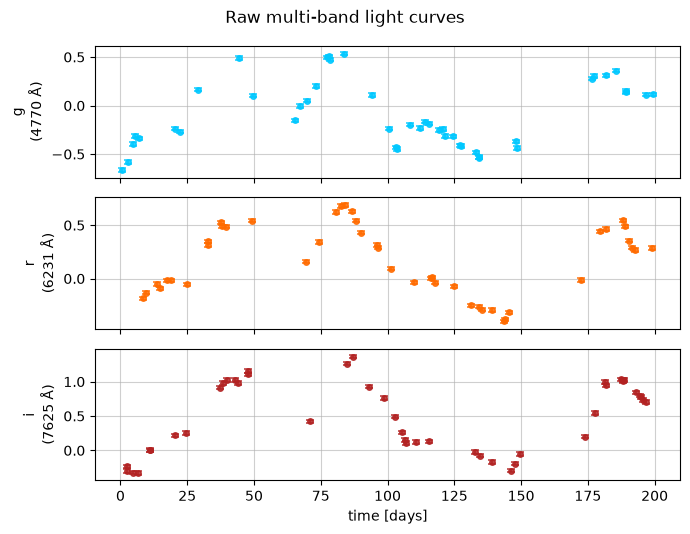

In [4]:
ef.plot_raw_lightcurves();

<a id="fit-nuts"></a>

## 4. Fit with NUTS

`EchoFit.fit()` runs NumPyro's **NUTS** (No-U-Turn Sampler) -- a self-tuning
variant of Hamiltonian Monte Carlo. All parameters are updated *jointly*
per iteration via gradient-guided trajectories (not one-at-a-time like
Metropolis-within-Gibbs, and not an ensemble of walkers like
affine-invariant/emcee-style sampling). During warmup, NumPyro adapts the
step size (to hit `target_accept_prob`) and a mass matrix automatically --
no manual leapfrog-step tuning needed.

A short chain is used here for a fast demo; for a real analysis, increase
`num_warmup`/`num_samples` substantially and check `ef.extra_fields` and
`ef.plot_mcmc_diagnostics()` below for signs of poor mixing.

Useful knobs (see the `EchoFit.fit`/`inference.run_mcmc` docstrings):
`max_tree_depth` bounds worst-case per-sample cost if NUTS is spending most
samples at its max-tree-depth ceiling; `chain_method="vectorised"` gets
extra chains for R-hat/ESS near-"free" when a run is dominated by fixed
per-call overhead rather than raw compute. **`dense_mass=True` is worth
trying for most real runs**: `scripts/profile_pipeline.py` found this
model's default diagonal mass matrix makes NUTS spend nearly every sample
pinned at the max-tree-depth ceiling (mean ~858 leapfrog steps/sample);
`dense_mass=True` cut that ~7.5x at no loss of recovery accuracy, at the
cost of needing a longer `num_warmup` to adapt the (much larger) mass
matrix properly -- see `CLAUDE.md` decision #17. **`drw_prior`** (set on
`EchoFit(...)`, not `.fit()`) chooses the driver's prior family --
`False` (default, used below) is a pure random-walk power law; `True`
restores the original damped random walk with `tau_drw` inferred too --
see Section 1 and `CLAUDE.md` decision #19.

In [5]:
ef.fit(rng_seed=0, num_warmup=400, num_samples=400, num_chains=1)

  0%|          | 0/800 [00:00<?, ?it/s]

warmup:   0%|          | 1/800 [00:06<1:24:26,  6.34s/it, 1 steps of size 2.13e+00. acc. prob=0.00]

warmup:   6%|▌         | 46/800 [00:06<01:14, 10.07it/s, 255 steps of size 2.78e-03. acc. prob=0.78]

warmup:   9%|▉         | 73/800 [00:07<00:56, 12.89it/s, 1023 steps of size 3.12e-03. acc. prob=0.80]

warmup:  11%|█         | 89/800 [00:08<00:50, 14.03it/s, 1023 steps of size 2.64e-03. acc. prob=0.80]

...

sample:  88%|████████▊ | 701/800 [00:14<00:00, 264.20it/s, 63 steps of size 9.15e-02. acc. prob=0.97]

sample:  91%|█████████ | 728/800 [00:14<00:00, 264.39it/s, 63 steps of size 9.15e-02. acc. prob=0.97]

sample:  95%|█████████▍| 757/800 [00:14<00:00, 268.68it/s, 63 steps of size 9.15e-02. acc. prob=0.97]

sample:  98%|█████████▊| 784/800 [00:14<00:00, 258.48it/s, 63 steps of size 9.15e-02. acc. prob=0.97]

sample: 100%|██████████| 800/800 [00:14<00:00, 53.80it/s, 63 steps of size 9.15e-02. acc. prob=0.97] 

<a id="inspect-posterior"></a>

## 5. Inspect the posterior

`ef.samples` is a dict of posterior draws per parameter. `ef.extra_fields`
carries NUTS diagnostics (e.g. `"diverging"`) -- **divergent transitions are
a red flag** for a badly parameterised model or a mismatched frequency
grid; don't trust a fit with a substantial fraction of them.

In [6]:
diverging = np.asarray(ef.extra_fields["diverging"])
print(f"Divergent transitions: {int(diverging.sum())}/{len(diverging)}")

print(f"\n{'parameter':<12}{'mean':>10}{'std':>10}")
for name in ["log_mdot", "inclination", "sigma_drw"]:  # tau_drw only exists if drw_prior=True
    s = np.asarray(ef.samples[name])
    print(f"{name:<12}{s.mean():>10.3f}{s.std():>10.3f}")

Divergent transitions: 0/400

parameter         mean       std
log_mdot         0.085     0.030
inclination     48.298    18.553
sigma_drw        0.138     0.080


<a id="visualise-fit"></a>

## 6. Visualise the fit

Three complementary views:

- **`plot_lightcurve_fits()`**: posterior-predictive light curves (68%/95%
  credible bands) against the data, with the **inferred driving light
  curve** in its own panel on top (time-aligned with the echo panels below
  it) and each band's response function `ψ(τ)` alongside it. The plotted
  range extends 30 days before/after the data (`extrapolate_days`) -- for a
  DRW-like driver the credible band should widen roughly like `t^(1/2)`
  outside the data before saturating. (This only affects plotting, done
  *after* fitting -- it doesn't slow NUTS down, since the likelihood only
  ever sees the actual observation times.)
- **`plot_power_spectrum()`**: the driver's posterior power spectrum
  `P(w) = (S^2 + C^2) / (2 dw)` against the fitted prior shape -- a pure
  `w^-2` power law (`drw_prior=False`, the default used here) or the
  fitted DRW Lorentzian (`drw_prior=True`, from posterior
  `sigma_drw`/`tau_drw`) -- and a dotted `w^-2` reference line, a sanity
  check that the assumed prior is actually shaping the posterior driver as
  intended.
- **`plot_mcmc_diagnostics()`**: trace plots per parameter. These should
  look like noisy horizontal bands (well-mixed), not slow drifts or a chain
  stuck at one value.
- **`plot_corner()`**: joint `log_mdot`/inclination posterior + marginals,
  coloured per chain (in the style of Starkey, Horne & Villforth 2016
  Figure 6) -- chains landing in visibly different places is the same
  thing a Gelman-Rubin R-hat check would flag, made visible. There are also
  `plot_corner_bands()` (each band's offset/stretch parameters),
  `plot_corner_free_lag()` (only if any band used `lag_mode="free"`), and
  `plot_fourier_correlation()` (a correlation heatmap for the driver's
  Fourier coefficients -- a corner plot doesn't scale to `n_freq` often
  being in the tens). All four are included automatically in `report.html`
  (Section 11).

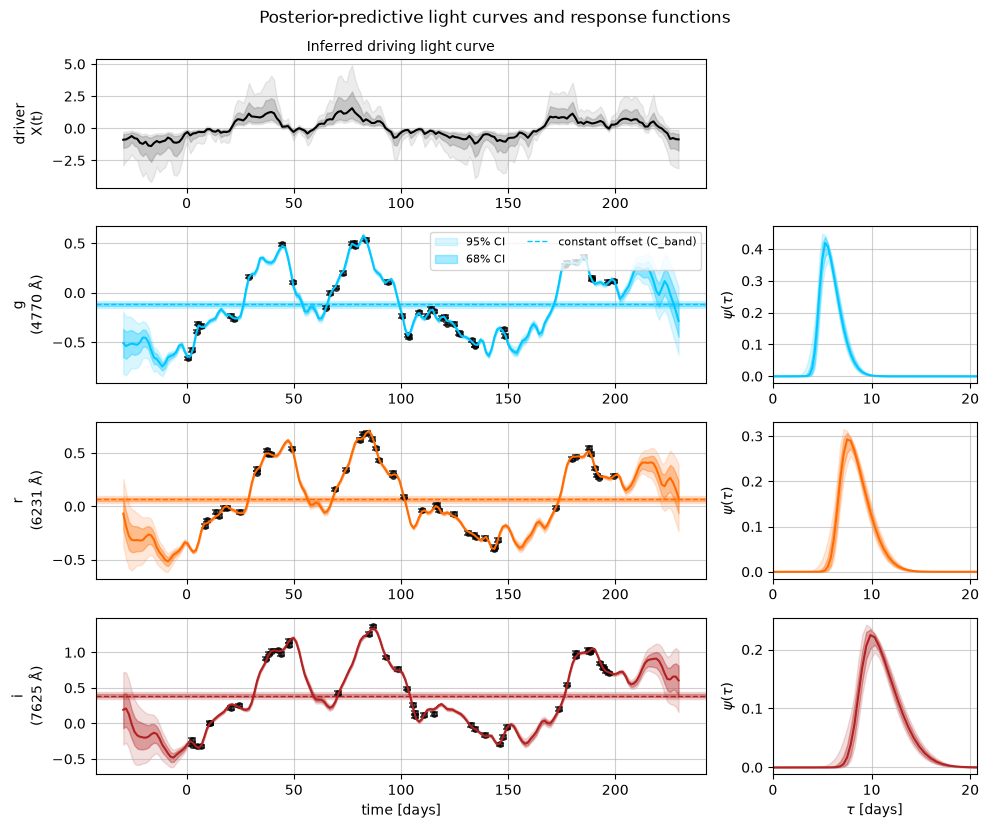

In [7]:
ef.plot_lightcurve_fits();

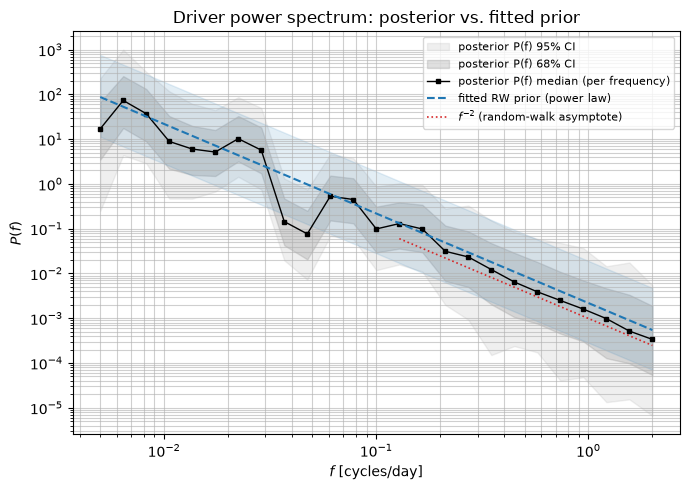

In [8]:
ef.plot_power_spectrum();

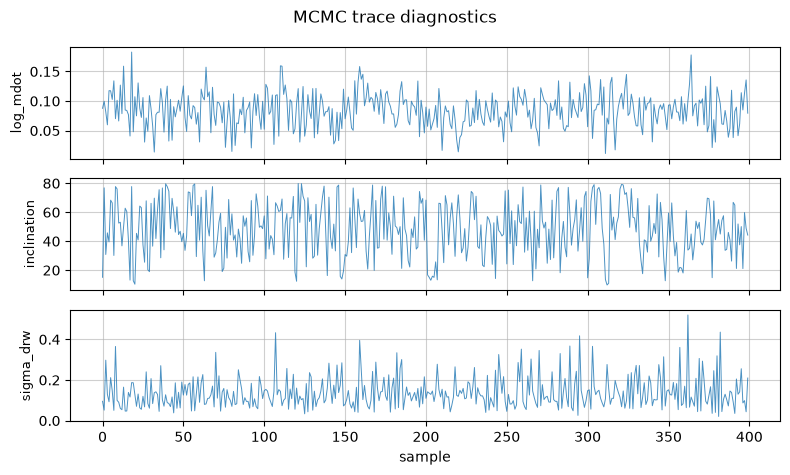

In [9]:
ef.plot_mcmc_diagnostics(param_names=["log_mdot", "inclination", "sigma_drw"]);

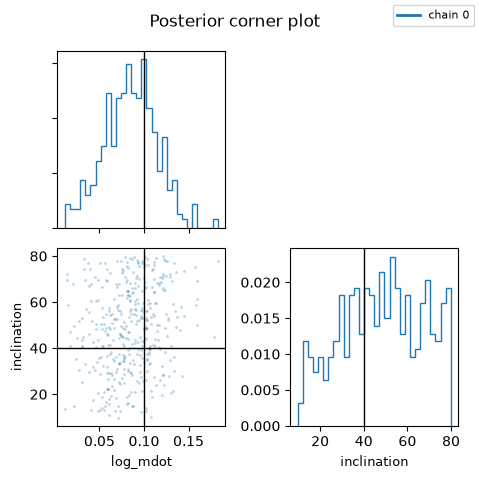

In [10]:
ef.plot_corner(true_values={"log_mdot": data["truth"]["log_mdot"], "inclination": data["truth"]["inclination"]});

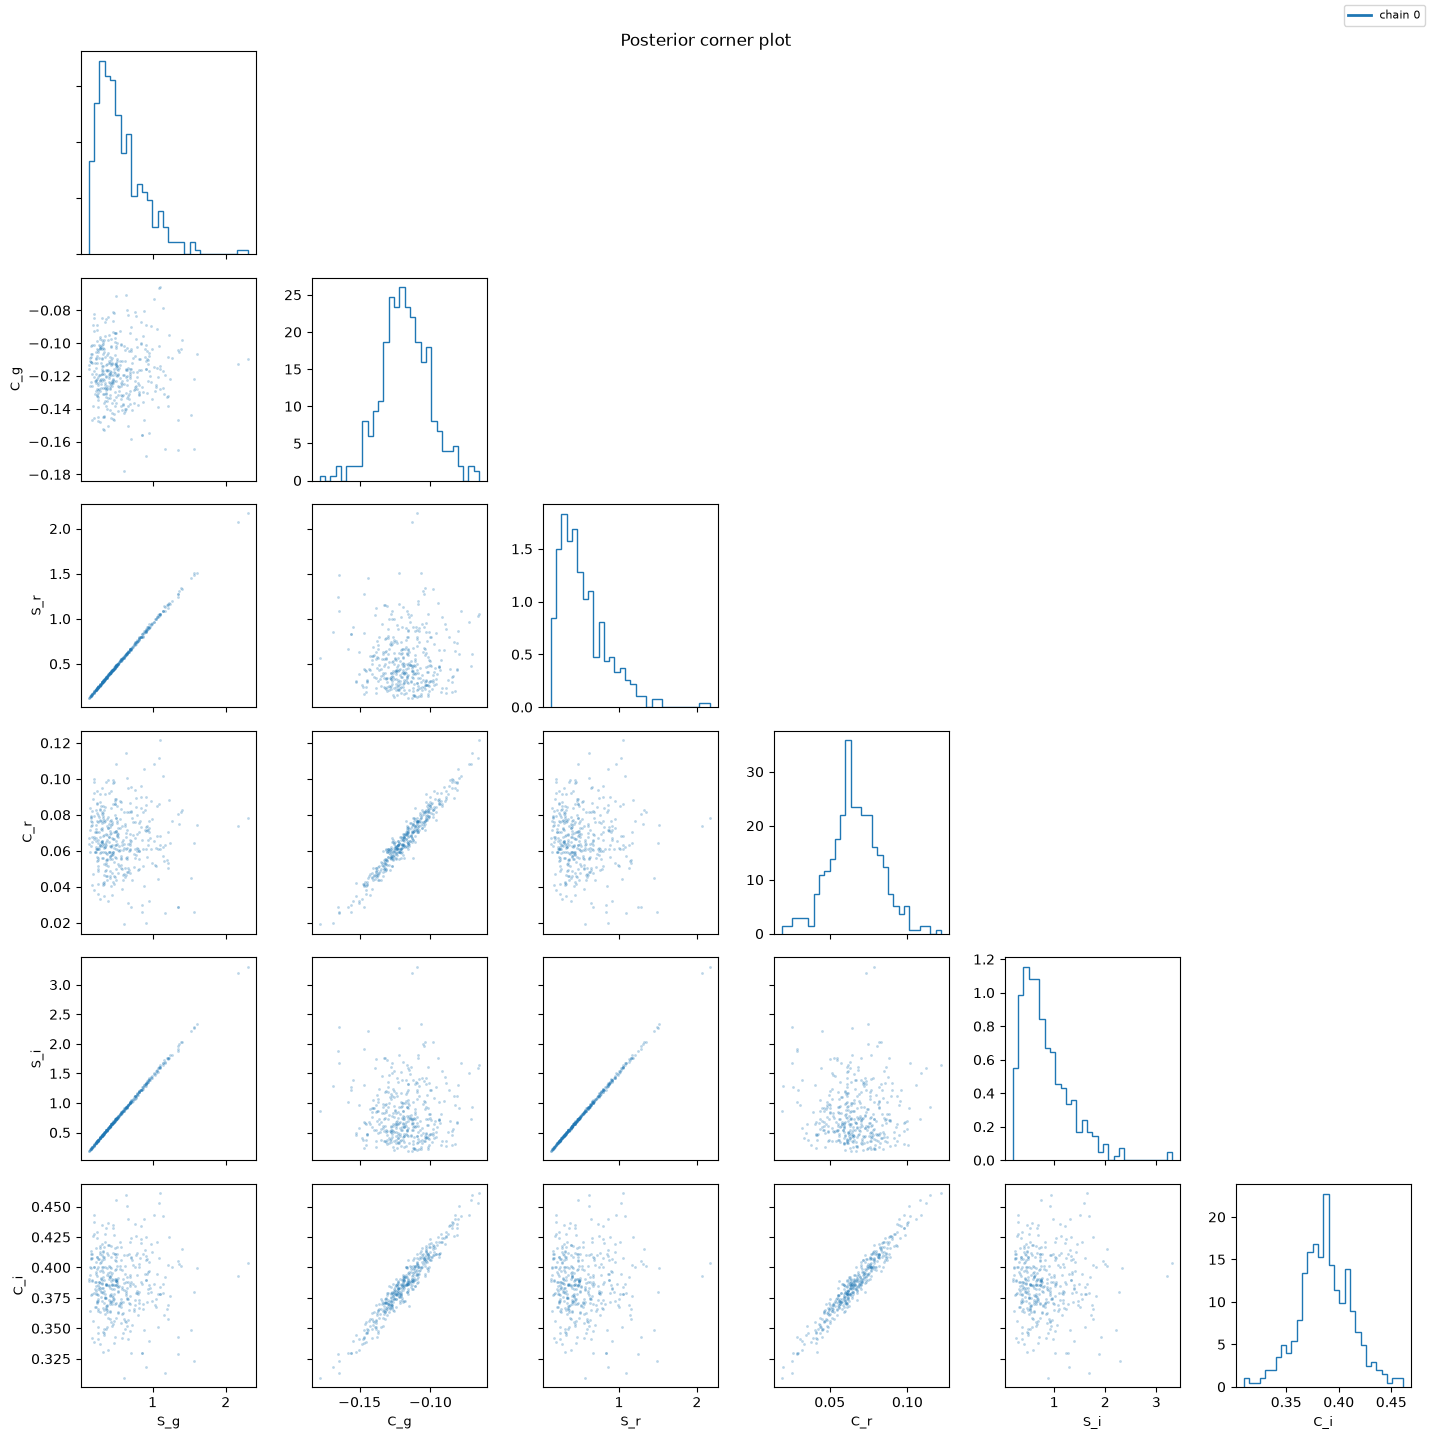

In [11]:
ef.plot_corner_bands();

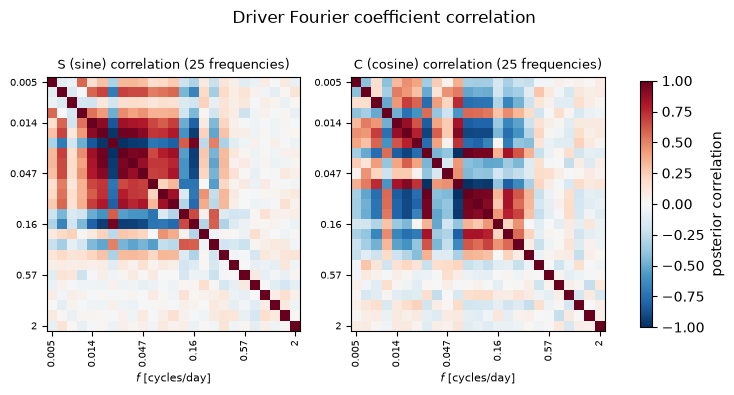

In [12]:
ef.plot_fourier_correlation();

<a id="sanity-check"></a>

## 7. Sanity check against ground truth

Since this is synthetic data, we know the truth. `log_mdot` (which sets the
mean lag -- the dominant signal in this forward model) should recover
fairly tightly; `inclination` (a subtler skew-only effect) is comparatively
weakly identified from a handful of bands/epochs, so don't be surprised by
a wide or somewhat-biased posterior for it even with zero divergences --
see `README.md`'s "Status / caveats" section.

`sigma_drw` is deliberately left out of the comparison below: the
synthetic truth was generated with a real damped random walk
(`tau_drw_true=25.0`, Section 2), but this fit uses the default
`drw_prior=False` random-walk prior, under which `sigma_drw` is a
power-law amplitude, not the DRW's saturating variability scale (see
Section 1) -- the two aren't the same quantity, so comparing the fitted
value against `tau_drw_true`'s companion `sigma_drw_true` wouldn't be a
meaningful check. `log_mdot` and `inclination` don't have this problem:
they're unaffected by which driver prior family the fit assumes.

In [13]:
truth = data["truth"]
for name in ["log_mdot", "inclination"]:
    post = ef.samples[name]
    print(f"{name}: true={truth[name]:.3f}  posterior median={np.median(post):.3f}  "
          f"[{np.percentile(post, 16):.3f}, {np.percentile(post, 84):.3f}]")

log_mdot: true=0.100  posterior median=0.085  [0.055, 0.113]
inclination: true=40.000  posterior median=48.758  [28.353, 69.639]


<a id="direct-solve"></a>

## 8. The fast direct solve: `optimise()` and the Badness-of-Fit landscape

`ef.optimise()` gives the posterior **without MCMC**, typically in a few
minutes. By default it uses a **nested Laplace approximation**
([`docs/nested_laplace.md`](../docs/nested_laplace.md)):

1. the driver's Fourier coefficients and the band offsets are integrated out
   *exactly* (everything is linear in them);
2. `log_mdot` and the inclination, the parameters whose posterior can be a
   curved valley or have two modes, are laid out on a grid;
3. at every grid point the few remaining parameters (`sigma_drw`, the band
   gains) are optimised and integrated with a Laplace (Gaussian)
   approximation, which is accurate for them;
4. draws from that grid are importance-weighted against the exact posterior,
   which corrects what the approximations miss and gives a reliability check,
   Pareto `k_hat` (trust the result below 0.7).

Because the grid covers `log_mdot` and inclination directly, it follows a
valley or finds a second mode where the older single-Gaussian solve,
`optimise(method="laplace")`, would report one peak with too small an error
bar. It costs roughly 1.5 times that solve, and a small fraction of NUTS.

The grid is also the best picture of what the data say about the disc:
`ef.plot_landscape()` shows it as Badness of Fit (BOF = -2 log posterior, as in
CREAM), over the whole prior range on the left and zoomed on the posterior,
with 68/95/99.7% contours, on the right.

Pareto k_hat = -0.02 (reliable below 0.7)

log_mdot: true 0.100 | NUTS 0.085 +/- 0.030 | optimise() 0.087 +/- 0.029
inclination: true 40.000 | NUTS 48.298 +/- 18.553 | optimise() 50.439 +/- 17.628


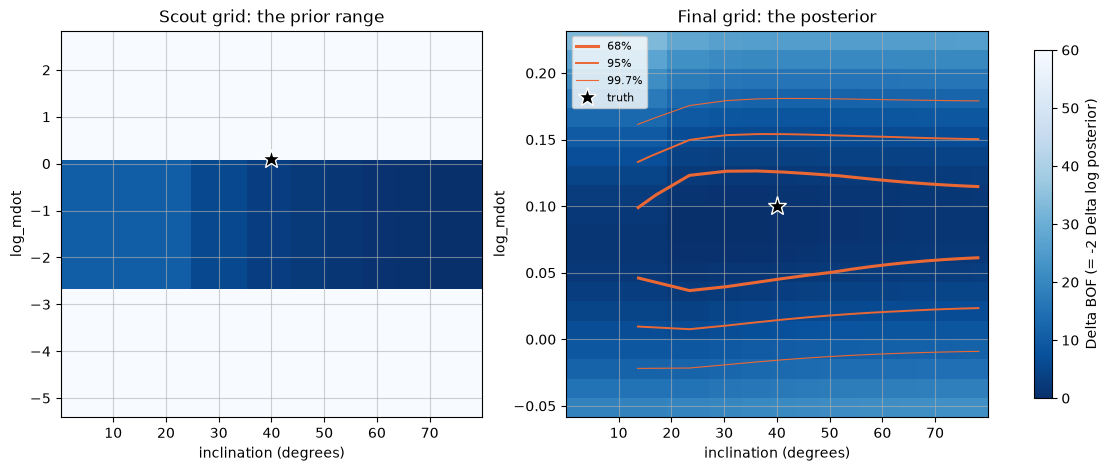

In [14]:
ef_direct = EchoFit(M_BH=M_BH_TRUE)
for name, d in data["bands"].items():
    ef_direct.add_lightcurve(name, wavelength=d["wavelength"], t=d["t"], y=d["y"], yerr=d["yerr"])
ef_direct.build_grid(n_freq=25, n_tau=150, period_max=PERIOD_MAX)

ef_direct.optimise()   # nested Laplace; optimise(method="laplace") for the single-Gaussian solve
print(f"Pareto k_hat = {ef_direct.nested_laplace_result['k_hat']:.2f} (reliable below 0.7)\n")
for name in ["log_mdot", "inclination"]:
    nuts, direct = ef.samples[name], ef_direct.samples[name]
    print(f"{name}: true {truth[name]:.3f} | NUTS {nuts.mean():.3f} +/- {nuts.std():.3f} | "
          f"optimise() {direct.mean():.3f} +/- {direct.std():.3f}")

ef_direct.plot_landscape(truth=truth);

<a id="fixed-params"></a>

## 9. Fixing parameters (e.g. assuming a face-on disk)

Any of the inferred scalar parameters (except `M_BH`, always fixed) can be
held fixed instead of sampled, via `EchoFit(fixed_params={...})`. A common
reason: assume a face-on disk (`inclination=0`) to make the remaining
parameters easier/faster to fit, e.g. when you don't care about
inclination for a particular analysis, or it's poorly constrained anyway.

Since inclination only ever affects the response's **skewness**, never the
**mean lag** (Section 1), `log_mdot` still recovers well below even though
we're deliberately fixing inclination to the *wrong* value here (the
synthetic truth is 40 degrees, not face-on) -- a face-on assumption trades
away skew information, not the mean-lag signal itself.

The same mechanism works for a free-lag band's `tau_{band}` (see
`README.md`'s "Emission-line / free-lag mode"), if you already know a
line's lag and want to hold it fixed while fitting everything else. A
`fixed_params` key that isn't a real site given the bands/driver actually
registered raises at `.fit()` time, to catch typos rather than silently
doing nothing.

In [15]:
ef_faceon = EchoFit(M_BH=M_BH_TRUE, fixed_params={"inclination": 0.0})

for name, d in data["bands"].items():
    ef_faceon.add_lightcurve(name, wavelength=d["wavelength"], t=d["t"], y=d["y"], yerr=d["yerr"])
ef_faceon.build_grid(n_freq=25, n_tau=150, period_max=PERIOD_MAX)

ef_faceon.fit(rng_seed=0, num_warmup=400, num_samples=400, num_chains=1, progress_bar=False)

print("'cos_inclination' sampled?", "cos_inclination" in ef_faceon.samples)  # not sampled at all
print("'inclination' values:", np.unique(ef_faceon.samples["inclination"]))  # constant, not a posterior

print(f"\nlog_mdot: true={truth['log_mdot']:.3f}  "
      f"posterior median={np.median(ef_faceon.samples['log_mdot']):.3f}  "
      f"(still recovers well despite the wrong fixed inclination)")

'cos_inclination' sampled? False
'inclination' values: [0.]

log_mdot: true=0.100  posterior median=0.057  (still recovers well despite the wrong fixed inclination)


<a id="error-model"></a>

## 10. Error-bar rescaling (`fit_error_model`)

Each light curve can optionally fit its own error rescaling instead of
trusting `yerr` exactly, via `add_lightcurve(..., fit_error_model=True)`
(or `add_driver_lightcurve(..., fit_error_model=True)`) -- off by default,
per light curve, so nothing changes unless you opt in.

When on, two extra nuisance parameters combine as
`sigma_eff = sqrt((sigma_scale*yerr)**2 + sigma_jitter**2)` in place of
`yerr` in the likelihood: `sigma_scale_{name}` (multiplicative, prior
centred on 1 -- "no rescaling") and `sigma_jitter_{name}` (additive,
anchored to that light curve's own typical quoted error). This is a
direct adaptation of the author's PhD-era CREAM Fortran code's own
`sigexpand`/`varexpand` parameters -- see `CLAUDE.md` decision #18 and
`docs/mcmc_implementation.md`'s Fortran comparison for where this came
from.

Since this synthetic data's `yerr` is correct by construction (it's
exactly the noise level used to generate `y`), turning `fit_error_model`
on for one band here is a good sanity check of the mechanism itself:
`sigma_scale_g` should recover close to 1 (no rescaling needed) and
`sigma_jitter_g` close to 0 (no extra floor needed), not a demonstration
of "fixing" anything wrong with this particular dataset. On real data with
under/over-estimated errors, you'd expect `sigma_scale` to land away from
1 instead.

In [16]:
ef_errmodel = EchoFit(M_BH=M_BH_TRUE)

for name, d in data["bands"].items():
    ef_errmodel.add_lightcurve(
        name, wavelength=d["wavelength"], t=d["t"], y=d["y"], yerr=d["yerr"],
        fit_error_model=(name == "g"),  # only band g opts in
    )
ef_errmodel.build_grid(n_freq=25, n_tau=150, period_max=PERIOD_MAX)

ef_errmodel.fit(rng_seed=0, num_warmup=400, num_samples=400, num_chains=1, progress_bar=False)

print("'sigma_scale_g' in samples?", "sigma_scale_g" in ef_errmodel.samples)
print("'sigma_scale_r' in samples?", "sigma_scale_r" in ef_errmodel.samples)  # band r didn't opt in

print(f"\nsigma_scale_g: posterior median={np.median(ef_errmodel.samples['sigma_scale_g']):.3f}  "
      f"(close to 1 -- yerr is correct by construction here)")
print(f"sigma_jitter_g: posterior median={np.median(ef_errmodel.samples['sigma_jitter_g']):.3f}  "
      f"(close to 0)")

'sigma_scale_g' in samples? True
'sigma_scale_r' in samples? False

sigma_scale_g: posterior median=0.855  (close to 1 -- yerr is correct by construction here)
sigma_jitter_g: posterior median=0.009  (close to 0)


<a id="managed-runs"></a>

## 11. Managed, resumable runs for real fitting campaigns

For a real analysis you'll want the run's data, config, progress, and
results saved to disk -- not just held in memory. Pass `title=` (e.g. an
AGN name) and `EchoFit` handles this for you: it writes
`<output_root>/<title>/run_<timestamp>/` containing the light curve data,
grids, periodic checkpoints, the final posterior (`chains.npz`, and
`chains.nc` if a netCDF backend is available), and the same visual report
you see above as `report.html` + PNGs.

**Output location** (highest to lowest priority): the `output_dir=`
argument, the `PYCREAM2_OUTPUT_DIR` environment variable, or `./outputs`
(relative to wherever you run your script/notebook from) -- gitignored by
default. We'll use an explicit `output_dir` here to keep this demo's output
next to the notebook rather than wherever Jupyter's cwd happens to be.

**If a fit is interrupted** (killed, crashed, machine restarted), resume it
in a new process with `EchoFit.resume(title)` -- it reloads the data,
config, and last checkpoint, and `.fit()` continues from exactly where it
left off (not from scratch), reusing the original settings. Scope note:
this only checkpoints the *sampling* phase (not warmup, and only single
chain -- see `README.md` for why).

In [17]:
demo_output_dir = os.path.join(os.getcwd(), "demo_outputs")

ef_managed = EchoFit(M_BH=M_BH_TRUE, title="demo_ngc_5548", output_dir=demo_output_dir)
for name, d in data["bands"].items():
    ef_managed.add_lightcurve(name, wavelength=d["wavelength"], t=d["t"], y=d["y"], yerr=d["yerr"])
ef_managed.build_grid(n_freq=25, n_tau=150, period_max=PERIOD_MAX)

# A shorter chain here since this cell is only demonstrating the run-
# management mechanics, not the fit quality (already checked above).
ef_managed.fit(rng_seed=0, num_warmup=150, num_samples=150, checkpoint_every=50, progress_bar=False)

print("\nRun directory:", ef_managed.run_dir)

  checkpoint: 50/150 samples saved.


  checkpoint: 100/150 samples saved.


  checkpoint: 150/150 samples saved.


Report written to /Users/david/projects/datascience_projects/echofit/notebooks/demo_outputs/demo_ngc_5548/run_20261008_205022/report.html

Run directory: /Users/david/projects/datascience_projects/echofit/notebooks/demo_outputs/demo_ngc_5548/run_20261008_205022


In [18]:
for p in sorted(ef_managed.run_dir.rglob("*")):
    if p.is_file():
        print(p.relative_to(ef_managed.run_dir))

bof.png
chains.nc
chains.npz
checkpoint/extra_fields.npz
checkpoint/samples.npz
checkpoint/state.pkl
corner.png
corner_bands.png
data.npz
fourier_correlation.png
grid.npz
lightcurve_fits.png
manifest.json
mcmc_diagnostics.png
power_spectrum.png
raw_lightcurves.png
report.html


In [19]:
# Resuming: in a real interruption you'd do this in a *new* process/session.
# Here the run already completed, so this is a safe no-op -- exactly what
# happens if you call .resume().fit() again out of habit after a run finished.
ef_resumed = EchoFit.resume("demo_ngc_5548", output_dir=demo_output_dir)
ef_resumed.fit(progress_bar=False)
print("Resumed instance sample count:", len(ef_resumed.samples["log_mdot"]))

Found checkpoint: 150/150 samples already collected.
'demo_ngc_5548' at /Users/david/projects/datascience_projects/echofit/notebooks/demo_outputs/demo_ngc_5548/run_20261008_205022 is already complete (150/150 samples) -- nothing to resume.


Report written to /Users/david/projects/datascience_projects/echofit/notebooks/demo_outputs/demo_ngc_5548/run_20261008_205022/report.html
Resumed instance sample count: 150


<a id="real-data"></a>

## 12. Using your own real light curves

The pattern is exactly the Quickstart above, just with your own arrays
instead of `generate_synthetic_dataset`'s output:

```python
import numpy as np
# t, y, yerr are your own arrays -- e.g. loaded with pandas/astropy from a
# CSV, a FITS table, whatever your pipeline already produces.
t_g, y_g, yerr_g = np.loadtxt("my_data/g_band.dat", unpack=True)
t_i, y_i, yerr_i = np.loadtxt("my_data/i_band.dat", unpack=True)

ef = EchoFit(M_BH=1.5e8, title="my_agn")   # use your own M_BH estimate
ef.add_lightcurve("g", wavelength=4770.0, t=t_g, y=y_g, yerr=yerr_g)
ef.add_lightcurve("i", wavelength=7625.0, t=t_i, y=y_i, yerr=yerr_i)
ef.build_grid()
ef.fit(num_warmup=1000, num_samples=2000)
```

Before trusting the result, it's worth checking two things this notebook
covers above:

1. **Lag resolvability** (Section 2): is the expected lag at your `M_BH`
   large relative to your cadence? `print(ef.freqs.min(), ef.freqs.max())`
   after `build_grid()` shows the frequency range the fit will actually use.
2. **Divergences and mixing** (Sections 5-6): check `ef.extra_fields`,
   `ef.plot_mcmc_diagnostics()`, and `ef.plot_power_spectrum()` before
   reading much into the posterior.

For a quick sanity check on a smaller scale before committing to a long
run, `python scripts/smoke_test.py` runs the whole pipeline end-to-end in
well under a minute on synthetic data.

<a id="swap-response"></a>

## 13. Swapping the response function

`forward_model.response_function` is the single place the response shape
lives; any replacement just needs to accept
`(tau_grid, log_mdot, wavelength, inclination, M_BH, ...)` and return a
causal, area-normalised array on `tau_grid` (see `CLAUDE.md`'s design
decision #5). `model.reverberation_model` looks up `response_function` by
name in `model.py`'s module namespace at call time, so for quick
experiments you can monkeypatch it directly -- no source edits needed.

Two response families ship with `pycream2`, discoverable via
`pycream2.responses`: the default `response_function` (a cheap skew-normal
shape) and `thin_disk_response` (a real accretion-disk response following
Starkey, Horne & Villforth 2016 -- viscous + lamppost-irradiation
temperature profile, the disk's own light-travel-time delay surface,
Planck-derivative response weighting, reduced to an exact analytic
integral over azimuth rather than needing a numerical radius/azimuth
grid, with a causal smoothing step on top, a 5 per cent Gaussian in ln tau,
in place of the original Fortran model's Gaussian deposit). Swap to it the same way:
`model_mod.response_function = get_response("thin_disk")`.

For an actual fit, `build_thin_disk_response_fast` precomputes the disk
response once across an inclination grid, then gets any inclination via
interpolation and any accretion rate/wavelength by stretching the lag axis
(the same precompute-and-stretch trick used in the original CREAM Fortran
code) for a further ~1.3-1.5x speedup over calling `thin_disk_response`
directly --
`model_mod.response_function = build_thin_disk_response_fast(M_BH=M_BH_TRUE)`.
See [`docs/thin_disk_response.md`](../docs/thin_disk_response.md) for
exactly how both are computed, scaling-law verification charts, the
smoothing step, and how much accuracy
the fast path's stretch approximation trades away (worst at high
inclination, far from the table's reference wavelength/accretion rate).

The cell below instead demonstrates a fully custom, user-written response
(a boxcar) with a deliberately short chain just to show the swap runs
end-to-end -- don't read anything into the fit quality below (it's not the
same response family the data was generated with, and 150 samples isn't
tuned for convergence the way Section 4's fit was).

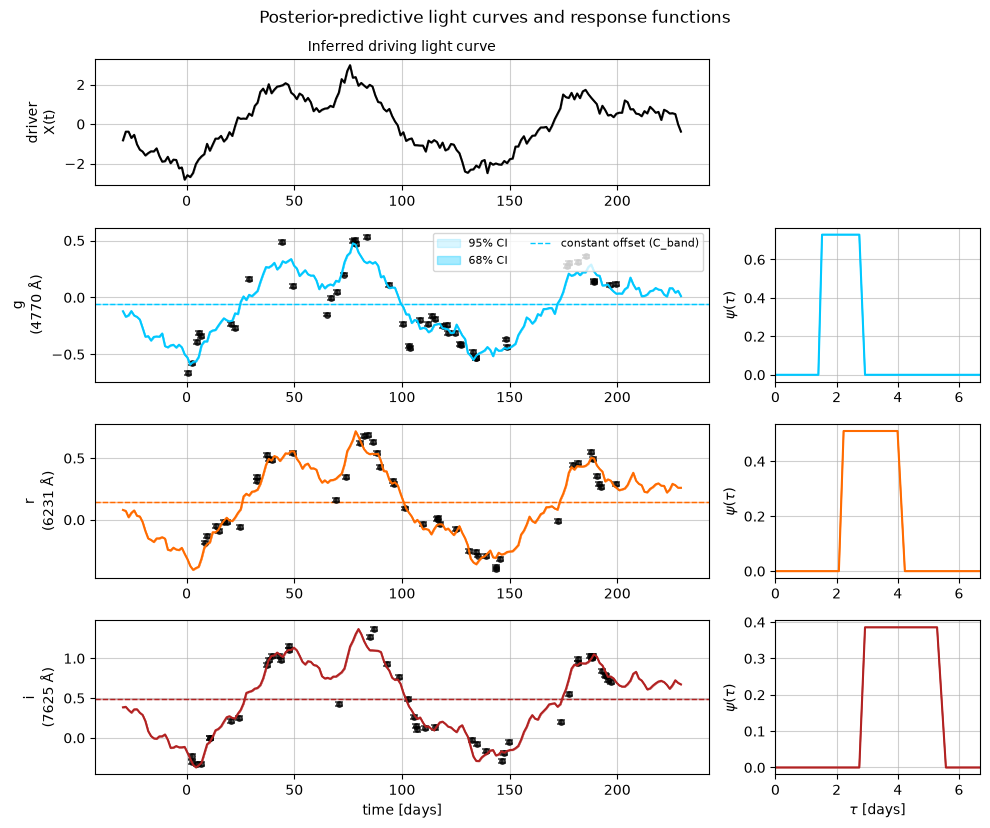

In [20]:
import jax.numpy as jnp
import pycream2.model as model_mod
from pycream2.forward_model import lag_scaling


def tophat_response(tau_grid, log_mdot, wavelength, inclination, M_BH, width_frac=0.3):
    # A boxcar response instead of the default skew-normal -- same mean
    # lag (from lag_scaling), no skewness.
    tau_mean = lag_scaling(log_mdot, wavelength, M_BH)
    half_width = jnp.clip(width_frac * tau_mean, 1e-3, None)
    raw = jnp.where(jnp.abs(tau_grid - tau_mean) <= half_width, 1.0, 0.0)
    trapz = jnp.trapezoid if hasattr(jnp, "trapezoid") else jnp.trapz
    area = trapz(raw, tau_grid)
    return raw / jnp.clip(area, 1e-12, None)


original_response_function = model_mod.response_function
model_mod.response_function = tophat_response

ef_tophat = EchoFit(M_BH=M_BH_TRUE)
for name, d in data["bands"].items():
    ef_tophat.add_lightcurve(name, wavelength=d["wavelength"], t=d["t"], y=d["y"], yerr=d["yerr"])
ef_tophat.build_grid(n_freq=25, n_tau=150, period_max=PERIOD_MAX)
ef_tophat.fit(rng_seed=0, num_warmup=150, num_samples=150, progress_bar=False)

ef_tophat.plot_lightcurve_fits();

model_mod.response_function = original_response_function  # restore for the rest of the notebook

<a id="extra-components"></a>

## 14. Extra components: diffuse continuum and slow backgrounds

Two optional components, both **off by default** and switched on per light curve:

- `diffuse_continuum=True` adds a second reprocessor with a **log-normal delay distribution** to a band's response, as for diffuse continuum emission from the broad-line region (Cackett, Zoghbi & Ulrich 2022): `psi = (1 - f) psi_disc + f psi_LN`. It has three parameters per band: `dce_fraction_{band}` (`f`, the diffuse component's share of the integrated response), `dce_delay_{band}` (median delay, days) and `dce_width_{band}` (rms width, dex).
- `background_order=K` adds a **slowly varying background**, `K` Legendre polynomials in time with coefficients `bg_{band}`, for variability unrelated to reverberation (cf. detrending, Welsh 1999). The coefficients are linear, so `optimise()` integrates them out exactly.

Below, synthetic light curves get a diffuse continuum in the three reddest bands and slow trends in `u` and `z`. We fit them with and without the components, using the direct solve. Ignoring the components biases the disc's `log_mdot`; including them recovers it and the injected components, and the Laplace evidence (`ef.log_evidence`) prefers them. See [`docs/extra_components.md`](../docs/extra_components.md) for the motivation, the mathematics and a larger recovery study.

In [21]:
import warnings

import numpy as np
from pycream2 import EchoFit
from pycream2.synthetic import generate_synthetic_dataset

dce_truth = {"r": (0.2, 8.0, 0.25), "i": (0.3, 8.0, 0.25), "z": (0.4, 8.0, 0.25)}  # (fraction, median delay d, width dex)
bg_truth = {"u": [0.4, -0.2], "z": [-0.3, 0.15]}  # Legendre coefficients
data_x = generate_synthetic_dataset(M_BH=1e8, log_mdot_true=0.3, inclination_true=35.0, n_obs_per_band=120,
                                    t_span=250.0, noise_level=0.03, seed=11,
                                    diffuse_continuum=dce_truth, background=bg_truth)


def direct_solve(with_components):
    ef = EchoFit(M_BH=1e8)
    for name, d in data_x["bands"].items():
        ef.add_lightcurve(name, d["wavelength"], d["t"], d["y"], d["yerr"],
                          diffuse_continuum=with_components and name in dce_truth,
                          background_order=2 if with_components and name in bg_truth else 0)
    ef.build_grid(tau_max=60.0, period_max=2 * np.pi / float(data_x["freqs"].min()))  # the truth's basis
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        ef.optimise(num_samples=300)
    return ef


ef_plain, ef_extra = direct_solve(False), direct_solve(True)
for label, ef in (("without components", ef_plain), ("with components", ef_extra)):
    s = ef.samples
    print(f"{label:19s} log_mdot = {s['log_mdot'].mean():.3f} +/- {s['log_mdot'].std():.3f} (true 0.3), "
          f"inclination = {s['inclination'].mean():.0f} +/- {s['inclination'].std():.0f} deg (true 35), "
          f"ln Z = {ef.log_evidence:.1f}")
s = ef_extra.samples
for band, (f, m, w) in dce_truth.items():
    print(f"{band}: fraction {s[f'dce_fraction_{band}'].mean():.2f} (true {f}), "
          f"median delay {s[f'dce_delay_{band}'].mean():.1f} d (true {m}), width {s[f'dce_width_{band}'].mean():.2f} dex (true {w})")
for band, coeffs in bg_truth.items():
    print(f"{band}: background {np.round(s[f'bg_{band}'].mean(axis=0), 3)} (true {coeffs})")

without components  log_mdot = 1.175 +/- 0.008 (true 0.3), inclination = 13 +/- 1 deg (true 35), ln Z = -20598.3
with components     log_mdot = 0.332 +/- 0.021 (true 0.3), inclination = 48 +/- 19 deg (true 35), ln Z = 1035.6
r: fraction 0.23 (true 0.2), median delay 7.0 d (true 8.0), width 0.28 dex (true 0.25)
i: fraction 0.40 (true 0.3), median delay 6.1 d (true 8.0), width 0.36 dex (true 0.25)
z: fraction 0.43 (true 0.4), median delay 7.5 d (true 8.0), width 0.29 dex (true 0.25)
u: background [ 0.406 -0.202] (true [0.4, -0.2])
z: background [-0.293  0.138] (true [-0.3, 0.15])


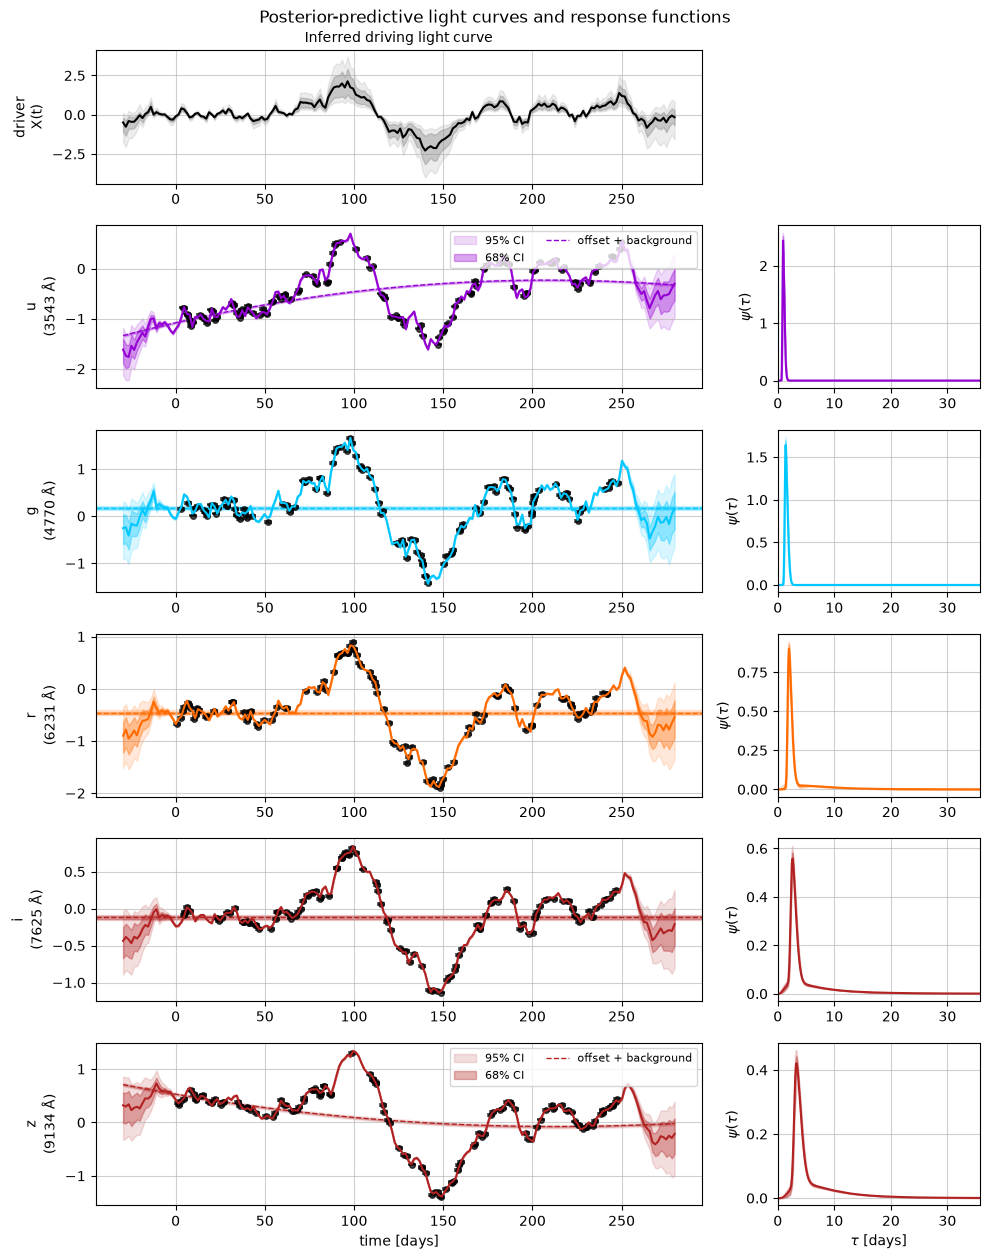

In [22]:
import matplotlib.pyplot as plt

fig, axes = ef_extra.plot_lightcurve_fits()
plt.show()

The response panels show each band's mixed response (disc plus diffuse continuum), and the model curves include the fitted backgrounds. Both are switched on per light curve, so you can give the diffuse continuum to the bands where you expect it (redder bands, and bands containing the Balmer or Paschen jump) and a background only where a slow trend is visible. Keep a component only if `log_evidence` rises.

<a id="disc-sed"></a>

## 15. Disc SED, luminosity distance and H0

The delays fix the disc's temperature profile in light-days, so the model disc's flux depends only on its distance: comparing it with the observed disc flux gives the luminosity distance, and with the redshift, $H_0$ (Cackett, Horne & Winkler 2007). `EchoFit(redshift=..., flux_unit=..., ebv_galactic=..., sed_analysis=True)` runs this after every `fit()`/`optimise()` and adds it to the report; `ef.disc_sed_analysis()` runs it on demand. It needs **absolute fluxes** (not normalised light curves) and **rest-frame** wavelengths.

The figure shows the flux-flux diagram, the variable (bright minus faint) SED against the spectrum of the disc's predicted response, the mean SED split into the model disc and the host (the bluest band is assumed host-free), and the $H_0$ posterior. Method, the two distance estimators and the caveats: `docs/disc_sed.md`. An implausible $H_0$ is a warning in itself: slow variability left out of the model makes the disc look larger and further away (fit `background_order`).

D_L = 133.1 Mpc (truth 131.4)
H0  = 69.1 +5.1/-2.3 km/s/Mpc (truth 70)
alpha from the variable SED: 0.74 (disc model: 0.75)


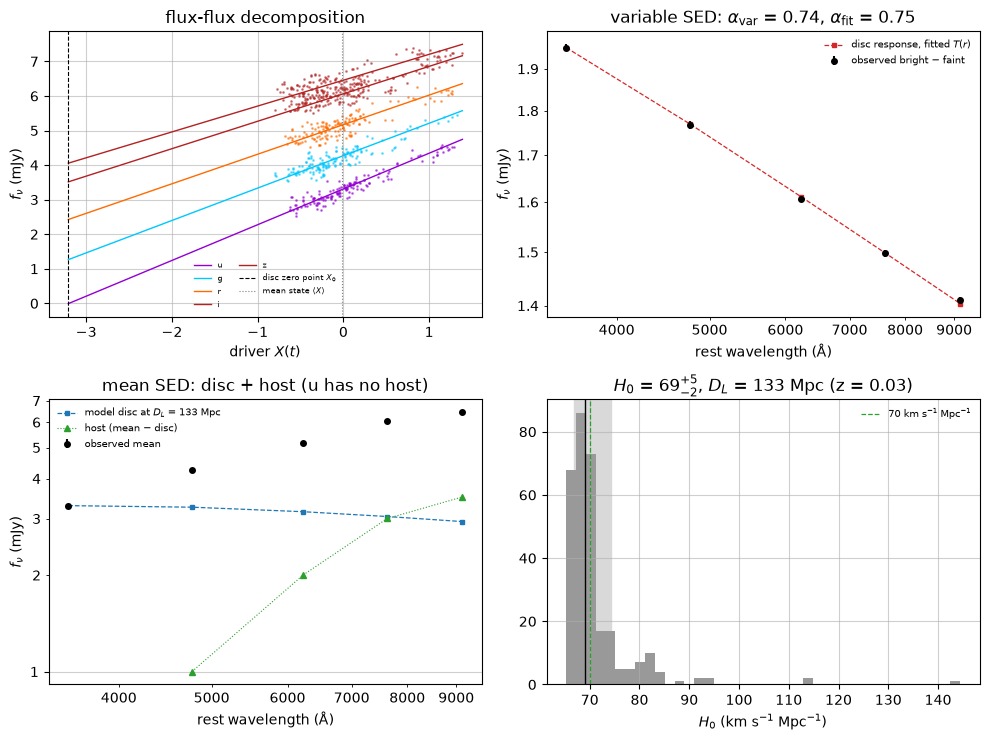

In [23]:
import warnings

from pycream2 import EchoFit
from pycream2.synthetic import generate_synthetic_dataset, with_disc_fluxes

# Synthetic light curves with absolute fluxes (mJy): a model disc at the distance
# H0 = 70 km/s/Mpc gives at z = 0.03, a host galaxy (none in u) and Galactic dust.
data_sed = with_disc_fluxes(
    generate_synthetic_dataset(M_BH=1e8, log_mdot_true=0.3, inclination_true=30.0, n_obs_per_band=150,
                               t_span=250.0, noise_level=0.03, seed=2),
    redshift=0.03, h0=70.0, host_mjy={"g": 1.0, "r": 2.0, "i": 3.0, "z": 3.5}, ebv_galactic=0.05,
)

ef_sed = EchoFit(M_BH=1e8, redshift=0.03, flux_unit="mJy", ebv_galactic=0.05, sed_analysis=True)
for name, d in data_sed["bands"].items():
    ef_sed.add_lightcurve(name, d["wavelength"], d["t"], d["y"], d["yerr"])
ef_sed.build_grid(tau_max=60, period_max=2 * np.pi / float(data_sed["freqs"].min()))  # the truth's basis
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    ef_sed.optimise(num_samples=500)   # the SED analysis runs automatically afterwards

s = ef_sed.disc_sed["summary"]
print(f"D_L = {s['dl_mpc'][1]:.1f} Mpc (truth {data_sed['truth']['disc_sed']['dl_mpc']:.1f})")
print(f"H0  = {s['h0'][1]:.1f} +{s['h0'][2] - s['h0'][1]:.1f}/-{s['h0'][1] - s['h0'][0]:.1f} km/s/Mpc (truth 70)")
print(f"alpha from the variable SED: {s['alpha_var'][1]:.2f} (disc model: 0.75)")
ef_sed.plot_disc_sed();


<a id="rippled-disc"></a>

## 16. Rimmed and rippled discs

`pycream2.rippled_disc` implements the rimmed and rippled discs of Starkey, Huang, Horne & Lin (2023, MNRAS 519, 2754). The disc has a thickness profile H(r): surfaces tilted towards the lamppost intercept more of its light, so they are hotter and respond more strongly than a flat disc at the same radius. A steep rim at ~5 light-days lengthens the optical delays a lot while barely changing the disc's spectrum, one proposed explanation of the disc-size problem.

`rippled_disc_response` has the usual response-function contract, with the geometry fixed (here the paper's NGC 5548 rim, `NGC5548_RIM`). Below: the responses and lag spectra of a flat disc and the rimmed disc. To fit with it, swap it in with `functools.partial`, as in section 13. Method, validation, an animation and a simulated fit: `docs/rippled_disc.md`.

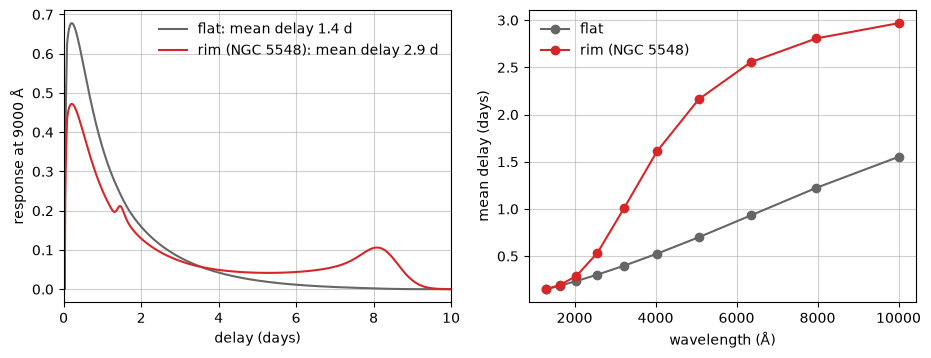

In [24]:
import functools

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from pycream2.grid_utils import graded_tau_grid
from pycream2.rippled_disc import NGC5548_RIM, mean_delay, rippled_disc_response

M_BH_RIM, LOG_MDOT_RIM, INCL_RIM = 7e7, 0.0587, 45.0   # a viscous disc at 1500 K at 5 light-days
tau = jnp.asarray(graded_tau_grid(30.0, 600))
discs = {"flat": dict(r_out=5.0, lamppost_efficiency=0.2), "rim (NGC 5548)": NGC5548_RIM}

fig, (ax_psi, ax_lag) = plt.subplots(1, 2, figsize=(11, 3.8))
lams = np.geomspace(1300.0, 10000.0, 10)
for (name, geom), colour in zip(discs.items(), ("0.4", "tab:red")):
    psi = rippled_disc_response(tau, LOG_MDOT_RIM, 9000.0, INCL_RIM, M_BH_RIM, **geom)
    ax_psi.plot(tau, psi, color=colour, label=f"{name}: mean delay {mean_delay(tau, psi):.1f} d")
    lags = [mean_delay(tau, rippled_disc_response(tau, LOG_MDOT_RIM, lam, INCL_RIM, M_BH_RIM, **geom)) for lam in lams]
    ax_lag.plot(lams, lags, "o-", color=colour, label=name)
ax_psi.set(xlim=(0, 10), xlabel="delay (days)", ylabel="response at 9000 Å")
ax_lag.set(xlabel="wavelength (Å)", ylabel="mean delay (days)")
for ax in (ax_psi, ax_lag):
    ax.legend(frameon=False)
    ax.grid(alpha=0.6)
plt.show()

# In a fit: model.response_function = functools.partial(rippled_disc_response, **NGC5548_RIM)

<a id="next-steps"></a>

## Next steps

- `python scripts/smoke_test.py` -- fast visual sanity check after code changes.
- `pytest` -- forward-model unit tests + end-to-end MCMC recovery/run-management tests.
- `README.md` -- full model writeup, package layout, and current status/caveats.
- `CLAUDE.md` -- design decisions and known rough edges, for anyone extending this codebase.